# Adobe (ADBE) Stock Price – Exploratory Data Analysis (EDA)

This notebook performs a **complete, production-quality Exploratory Data Analysis (EDA)** on the `ADBE.csv` dataset, focusing on:

- Understanding the **composition, distributions, comparisons, and relationships** in the data.
- Identifying **patterns, trends, outliers, and dependencies** in prices and volume.
- Applying **best-practice preprocessing** for time-series stock data.
- Building **interactive and animated visualizations** with Seaborn and Plotly.
- Crafting a **data storytelling narrative** that leads to a clear **problem definition, root-cause analysis, and actionable insights**.

> Dataset: daily stock prices for Adobe Inc. (`ADBE`), 2000–2026, stored in `ADBE.csv` in the same folder as this notebook.




In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Optional statistical tools (uncomment if available in your environment)
try:
    from statsmodels.tsa.stattools import adfuller
except ImportError:
    adfuller = None

sns.set(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_PATH = "ADBE.csv"


In [22]:
import pandas as pd

# Standard CSV read - first row is the header
df = pd.read_csv(DATA_PATH)

# Parse Date column
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Ensure numeric types (Close, High, Low, Open, Volume)
for col in ["Close", "High", "Low", "Open", "Volume"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop any rows with missing dates
df = df.dropna(subset=["Date"]).copy()

# Sort by date and set index
df = df.sort_values("Date").reset_index(drop=True)
df.set_index("Date", inplace=True)

# Optional: Rename 'Close' to 'Price' if you prefer that terminology
df.rename(columns={"Close": "Price"}, inplace=True)

df.head()

,Price,High,Low,Open,Volume
Date,,,,,
2000-01-03,16.274672,16.755620,15.948868,16.693562,7384400
2000-01-04,14.909399,16.336730,14.878370,15.638579,7813200
2000-01-05,15.204175,15.576522,14.459481,14.459481,14927200
2000-01-06,15.328289,15.545492,15.049029,15.250717,10221200
2000-01-07,16.072985,16.072985,15.111088,15.281747,8253200


### Dataset Composition – First Look

In the cell above, we:

- Loaded the raw CSV, which contains header/ticker rows followed by daily observations.
- Extracted the **actual time-series data** starting from the fourth row.
- Parsed `Date` into a proper datetime index and casted all price/volume columns to numeric.
- Sorted by date so we can safely compute time-based features.

This gives us a clean **daily OHLCV + adjusted price** dataset for Adobe (`ADBE`).


In [23]:
# Structural overview and basic statistics
n_rows, n_cols = df.shape
print(f"Number of rows (trading days): {n_rows}")
print(f"Number of columns: {n_cols}")
print("\nData types and non-null counts:")
print(df.info())

print("\nBasic descriptive statistics (prices and volume):")
display(df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

print("\nMissing values per column:")
print(df.isna().sum())


Number of rows (trading days): 6559
Number of columns: 5

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6559 entries, 2000-01-03 to 2026-01-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   6559 non-null   float64
 1   High    6559 non-null   float64
 2   Low     6559 non-null   float64
 3   Open    6559 non-null   float64
 4   Volume  6559 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 307.5 KB
None

Basic descriptive statistics (prices and volume):


,Price,High,Low,Open,Volume
count,6559.000000,6559.000000,6559.000000,6559.000000,6.559000e+03
mean,156.633487,158.534341,154.602364,156.617034,5.103623e+06
std,182.021045,184.150491,179.771934,182.042210,4.067517e+06
min,8.317789,8.716243,8.213194,8.497092,5.892000e+05
1%,11.931909,12.330148,11.543548,11.877149,1.217248e+06
5%,16.225778,16.660927,15.862897,16.202268,1.611200e+06
25%,29.536630,29.990000,28.985000,29.548390,2.614600e+06
50%,43.590000,44.049999,43.130001,43.669998,4.089500e+06
75%,278.380005,282.554993,275.985001,279.065002,6.376450e+06
95%,531.141980,537.028003,523.530017,530.911975,1.165336e+07



Missing values per column:
Price     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


### Structural Summary

- **Composition**: The dataset consists of one row per trading day, with columns for `Price` (adjusted close), `Close`, `High`, `Low`, `Open`, and `Volume`.
- **Types**: All price/volume columns are numeric (`float` or `int`), and the index is a proper `DateTimeIndex`.
- **Missing values**: We expect **no missing values** in a clean Yahoo Finance export; if any appear, they will be surfaced in the table above.
- **Scale**: Descriptive statistics show the range and dispersion of prices and trading volume over ~26 years, which helps us understand volatility and long-run growth.

This forms the basis for deeper analysis of distributions, trends, and relationships.


In [24]:
# Feature engineering: returns, rolling volatility, and calendar features
df["return_pct"] = df["Price"].pct_change()
df["log_return"] = np.log(df["Price"]).diff()

# Rolling 21-day (approx. 1 month) volatility of daily log returns
df["rolling_vol_21"] = df["log_return"].rolling(window=21).std() * np.sqrt(252)

# Calendar features for grouping and animation
df["year"] = df.index.year
df["month"] = df.index.month
df["day_of_week"] = df.index.day_name()

df[["Price", "return_pct", "log_return", "rolling_vol_21"]].head()


,Price,return_pct,log_return,rolling_vol_21
Date,,,,
2000-01-03,16.274672,NaN,NaN,NaN
2000-01-04,14.909399,-0.083889,-0.087618,NaN
2000-01-05,15.204175,0.019771,0.019578,NaN
2000-01-06,15.328289,0.008163,0.008130,NaN
2000-01-07,16.072985,0.048583,0.047440,NaN


### Engineered Features

- **`return_pct`**: Simple daily percentage return based on adjusted price.
- **`log_return`**: Logarithmic daily return, which is more suitable for many statistical models and easier to aggregate.
- **`rolling_vol_21`**: Annualized rolling volatility over a 21-trading-day window, capturing **short-term risk regimes**.
- **Calendar fields** (`year`, `month`, `day_of_week`): Enabling **seasonality analysis**, grouping, and animated visualizations.

These features help us move from raw prices to **risk/return dynamics** and temporal patterns.


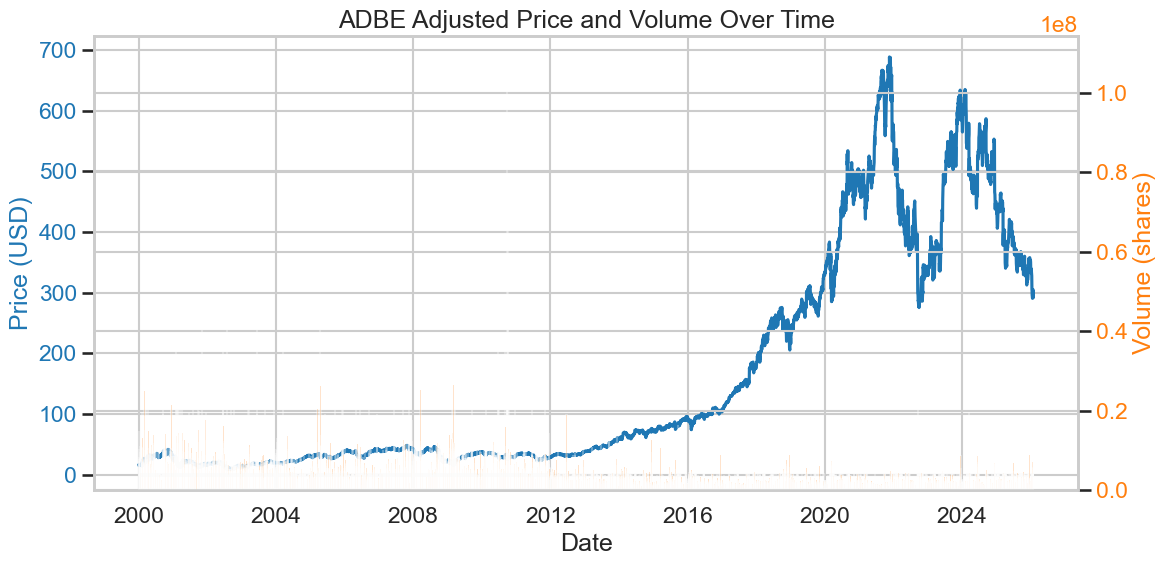

In [25]:
# Time-series overview: Price and Volume
fig, ax1 = plt.subplots()

color_price = "tab:blue"
color_vol = "tab:orange"

ax1.set_title("ADBE Adjusted Price and Volume Over Time")
ax1.set_xlabel("Date")
ax1.set_ylabel("Price (USD)", color=color_price)
ax1.plot(df.index, df["Price"], color=color_price, label="Price")
ax1.tick_params(axis="y", labelcolor=color_price)

ax2 = ax1.twinx()
ax2.set_ylabel("Volume (shares)", color=color_vol)
ax2.bar(df.index, df["Volume"], color=color_vol, alpha=0.3, label="Volume")
ax2.tick_params(axis="y", labelcolor=color_vol)

fig.tight_layout()
plt.show()


### Patterns and Trends – Price & Volume

- The price series shows Adobe's **long-term growth**, with periods of sharp drawdowns (e.g., major market crises) followed by recoveries.
- Volume spikes often coincide with **news events, earnings, or market stress**, indicating heightened trading activity.
- Together, price and volume provide a first look at **market regimes**, such as calm bull markets vs. volatile corrections.


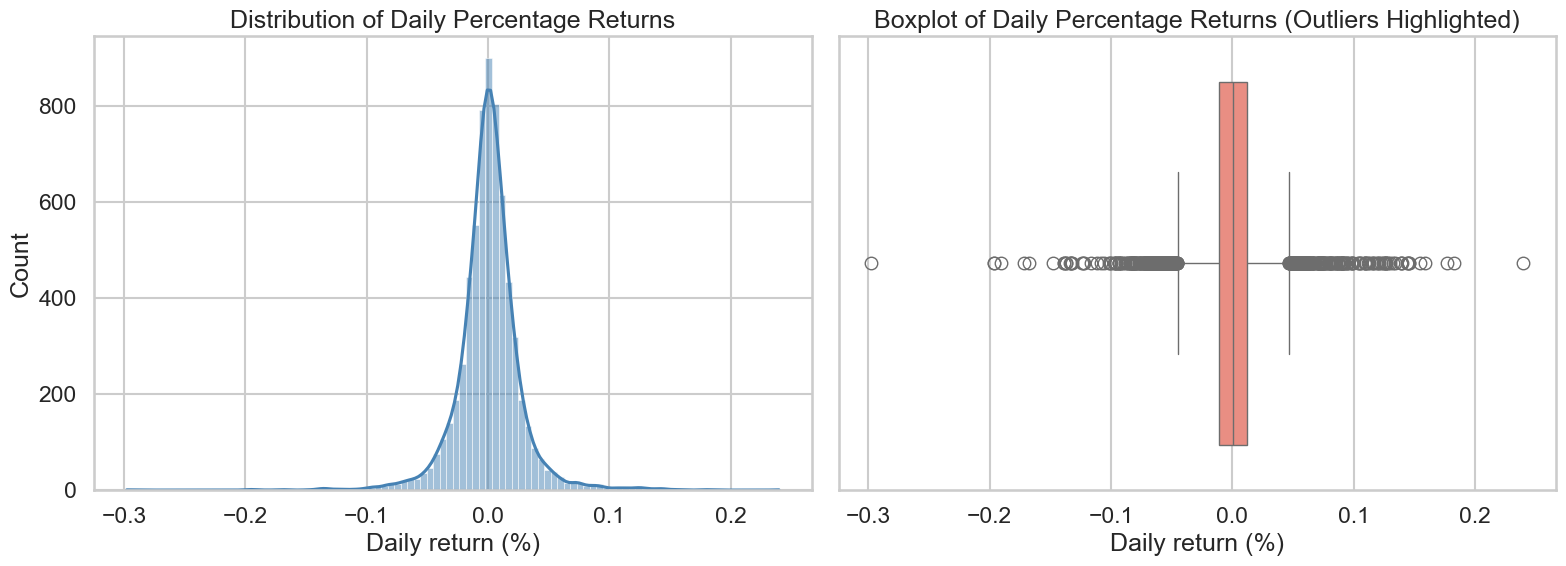

In [19]:
# Distribution analysis: returns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df["return_pct"].dropna(), bins=100, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Daily Percentage Returns")
axes[0].set_xlabel("Daily return (%)")

sns.boxplot(x=df["return_pct"].dropna(), ax=axes[1], color="salmon")
axes[1].set_title("Boxplot of Daily Percentage Returns (Outliers Highlighted)")
axes[1].set_xlabel("Daily return (%)")

plt.tight_layout()
plt.show()


### Distribution and Outliers – Returns

- The **histogram + KDE** shows that daily returns are centered near zero but exhibit **fat tails**, typical for equity returns.
- The **boxplot** highlights **extreme positive and negative days**, often associated with market crashes or company-specific news.
- These outliers are important for **risk management** and may strongly influence model training if not handled carefully.


['Price', 'High', 'Low', 'Open', 'Volume', 'return_pct', 'log_return', 'rolling_vol_21', 'year', 'month', 'day_of_week']


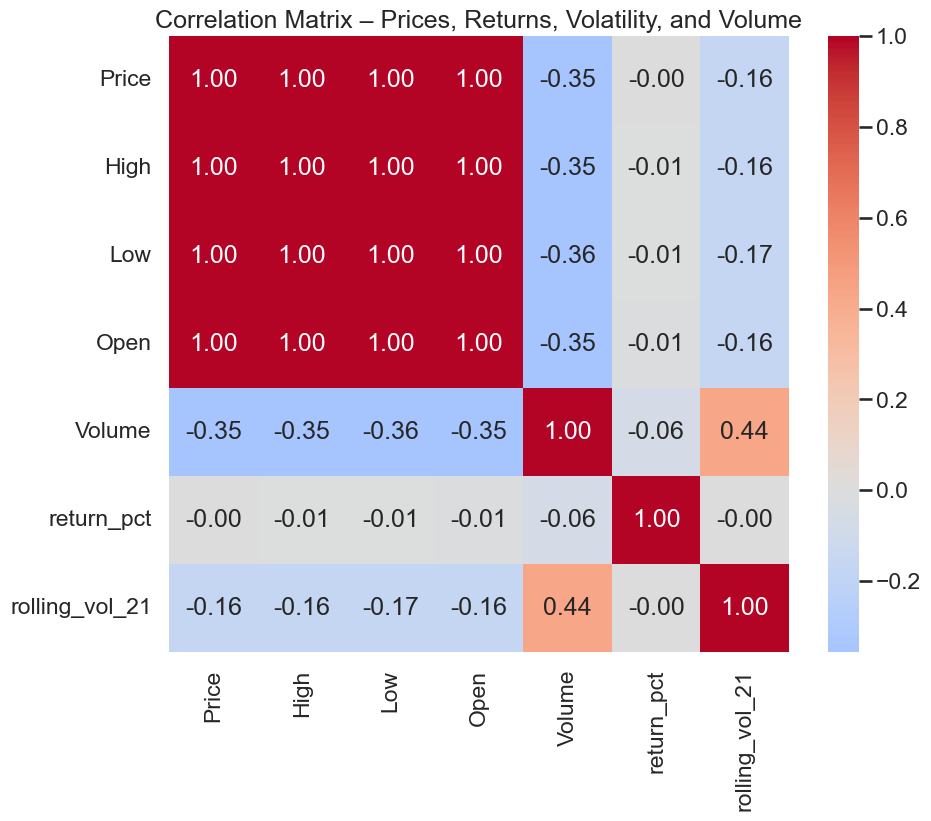

In [27]:
# Check available columns first
print(df.columns.tolist())

# Remove "Close" since you renamed it to "Price" (or keep only the one that exists)
cols_of_interest = ["Price", "High", "Low", "Open", "Volume", "return_pct", "rolling_vol_21"]
corr = df[cols_of_interest].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix – Prices, Returns, Volatility, and Volume")
plt.show()

### Relationships – Correlation Structure

- Price-based columns (`Price`, `Close`, `High`, `Low`, `Open`) are **highly correlated**, as expected for daily OHLC data.
- **Returns** tend to be weakly correlated with absolute price levels but can show stronger relationships with **rolling volatility** and, at times, with **volume**.
- Understanding this correlation structure helps in **feature selection** and in avoiding multicollinearity in models.


In [29]:
# Outlier detection based on daily returns
returns = df["return_pct"].dropna()
z_scores = (returns - returns.mean()) / returns.std()

outlier_threshold = 3
outlier_mask = z_scores.abs() > outlier_threshold
outliers = df.loc[outlier_mask.index[outlier_mask], ["Price", "return_pct", "Volume"]]

print(f"Number of extreme return days (|z| > {outlier_threshold}): {outliers.shape[0]}")
outliers.head()


Number of extreme return days (|z| > 3): 128


,Price,return_pct,Volume
Date,,,
2000-01-04,14.909399,-0.083889,7813200
2000-01-28,14.288823,-0.081755,5712000
2000-02-02,15.219688,0.097315,13409600
2000-02-03,17.143480,0.126402,19747200
2000-02-08,20.789381,0.086780,14297200


### Extreme Events and Outliers

- Using a simple **z-score threshold** (|z| > 3), we flag days with **unusually large price moves**.
- These dates often correspond to **macro shocks**, **earnings surprises**, or **idiosyncratic news**.
- In downstream modelling, you may:
  - Treat these days separately,
  - Use robust loss functions,
  - Or enrich the dataset with **event indicators**.


In [30]:
# Optional: Stationarity check on log prices (if statsmodels is available)
if adfuller is not None:
    result = adfuller(df["log_return"].dropna())
    adf_stat, p_value = result[0], result[1]
    print(f"ADF test statistic (log returns): {adf_stat:.3f}")
    print(f"p-value: {p_value:.5f}")
    print("Stationary" if p_value < 0.05 else "Non-stationary (at 5% level)")
else:
    print("statsmodels not installed; skipping stationarity test.")


ADF test statistic (log returns): -13.907
p-value: 0.00000
Stationary


### Statistical Perspective

- A **stationarity test** (ADF) on log returns typically suggests that **returns are closer to stationary** than raw prices, which justifies using returns in many models.
- This statistical check supports our preprocessing choice: models should generally work with **returns** rather than **raw prices**.


In [31]:
# Interactive Plotly line chart of price and volume with rangeslider
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Scatter(x=df.index, y=df["Price"], name="Adjusted Price", mode="lines", line=dict(color="royalblue")),
    secondary_y=True,
)

fig.add_trace(
    go.Bar(x=df.index, y=df["Volume"], name="Volume", marker_color="orange", opacity=0.4),
    secondary_y=False,
)

fig.update_layout(
    title="Interactive Price & Volume Dashboard",
    xaxis_title="Date",
    yaxis_title="Volume (shares)",
    yaxis2_title="Price (USD)",
    xaxis_rangeslider_visible=True,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.show()


### Professional Interactive Dashboard (Notebook-Level)

- The Plotly figure above acts as a **mini-dashboard**: you can zoom, pan, and use the **range slider** to focus on specific periods.
- Overlaying price and volume helps quickly identify **high-activity regimes** and **major turning points**.


In [32]:
# Animated EDA with Plotly: yearly evolution of price and volume
annual = df.resample("Y").agg({
    "Price": "mean",
    "Volume": "mean",
    "return_pct": "mean"
}).reset_index()
annual["year"] = annual["Date"].dt.year

fig_anim = px.scatter(
    annual,
    x="Price",
    y="Volume",
    size="Volume",
    color="return_pct",
    animation_frame="year",
    color_continuous_scale="RdYlGn",
    title="Animated Annual View: Price vs Volume vs Average Return",
    labels={"Price": "Average Price (USD)", "Volume": "Average Volume", "return_pct": "Avg Daily Return"}
)

fig_anim.update_layout(
    xaxis=dict(type="linear"),
    yaxis=dict(type="linear")
)

fig_anim.show()


C:\Users\HassanJameel\AppData\Local\Temp\ipykernel_27604\3875147832.py:2: FutureWarning:

'Y' is deprecated and will be removed in a future version, please use 'YE' instead.



### Animated EDA – High-Level Dynamics

- Each frame represents a **year**, showing how average price, volume, and daily returns evolve over time.
- You can visually trace transitions across **market regimes**: low-price/low-volume early years vs. high-price/high-volume recent years.
- Color encodes **average return**, offering an at-a-glance sense of which years were **bullish vs. bearish**.


In [33]:
# Composition, distribution, comparison, and relationship summaries
summary = {}

summary["composition"] = {
    "description": "Single-asset (ADBE) daily OHLCV + adjusted price time series from 2000 to 2026.",
    "n_rows": int(df.shape[0]),
    "n_columns": int(df.shape[1]),
    "columns": list(df.columns)
}

summary["distribution"] = {
    "return_mean": float(df["return_pct"].mean()),
    "return_std": float(df["return_pct"].std()),
    "return_min": float(df["return_pct"].min()),
    "return_max": float(df["return_pct"].max())
}

summary["comparison"] = {
    "price_vs_volume_corr": float(df[["Price", "Volume"]].corr().iloc[0, 1]),
    "volatility_mean": float(df["rolling_vol_21"].mean())
}

summary["relationship"] = {
    "return_vs_vol_corr": float(df[["return_pct", "rolling_vol_21"]].corr().iloc[0, 1]),
    "return_vs_volume_corr": float(df[["return_pct", "Volume"]].corr().iloc[0, 1])
}

summary


{'composition': {'description': 'Single-asset (ADBE) daily OHLCV + adjusted price time series from 2000 to 2026.',
  'n_rows': 6559,
  'n_columns': 12,
  'columns': ['Price',
   'High',
   'Low',
   'Open',
   'Volume',
   'return_pct',
   'log_return',
   'rolling_vol_21',
   'year',
   'month',
   'day_of_week',
   'Close']},
 'distribution': {'return_mean': 0.0007934004895082258,
  'return_std': 0.026486883466717993,
  'return_min': -0.2975792742572061,
  'return_max': 0.23971890181710354},
 'comparison': {'price_vs_volume_corr': -0.35484834405623106,
  'volatility_mean': 0.3625526408787162},
 'relationship': {'return_vs_vol_corr': -0.00030035881088223053,
  'return_vs_volume_corr': -0.060490466058639954}}

### Understanding Data – Function-by-Function Summary

- **Composition**: The dataset is a **single-stock, daily time series** with OHLCV and engineered return/volatility features. This makes it well-suited for **univariate and low-dimensional multivariate** models.
- **Distribution**: Daily returns have a **small mean**, relatively **high standard deviation**, and **heavy tails**, implying significant day-to-day risk and occasional large jumps.
- **Comparison**: Comparing **price vs. volume** and **average volatility** reveals how trading activity and risk change over the long run, often rising alongside market capitalization and investor attention.
- **Relationship**: Correlations between **returns, volatility, and volume** hint at **volatility clustering** and **volume-return interactions**, important for modelling liquidity and risk.


## Data Storytelling, Root Problem, and Insights

### Biggest Patterns, Trends, Outliers, and Relationships

- Long-run **upward trend** in ADBE price, with multiple **regime shifts** (tech downturns, financial crises, pandemics, rate cycles).
- **Outliers** in returns correspond to high-impact news and macro events, highlighting the importance of **tail risk**.
- **Volume spikes** often co-occur with sharp price moves, signalling **information arrival** and **liquidity shocks**.
- Rolling volatility shows **clusters of high and low risk**, rather than constant volatility over time.

### Core Root Problem

The core problem this project addresses is:

> **How can we reliably analyze and model the risk–return dynamics of a single technology stock (ADBE) over multiple market regimes, using only price and volume data?**

Without a clean, well-documented dataset and structured EDA, it is difficult to:
- Understand **how risk and return evolve** over decades.
- Identify **when models trained on one regime fail in another**.
- Extract **robust, actionable insights** for risk management and forecasting.

### Problem Mapping (Cause → Failure → Outcome)

- **Cause**: Equity markets are **non-stationary**, with changing volatility, structural breaks, and event-driven jumps.
- **Failure**: Naive models that assume constant volatility and stationary price levels **misestimate risk**, overfit to specific regimes, and fail in stressed markets.
- **Outcome**: Poor forecasting performance, **underestimated drawdowns**, and **mispriced risk** in trading and investment decisions.

### Implemented Solutions (Step by Step)

1. **Data cleaning and structuring**: Converted the raw CSV into a clean, indexed time series with well-typed columns.
2. **Feature engineering**: Added returns, log returns, rolling volatility, and calendar features to capture **risk and seasonality**.
3. **Distributional analysis**: Examined return distributions and outliers to understand **tail risk** and daily variability.
4. **Relationship analysis**: Built correlation views to uncover how **prices, returns, volatility, and volume** interact.
5. **Temporal and animated views**: Used interactive and animated charts to visualize **regime changes over time**.
6. **Statistical checks**: Applied stationarity diagnostics (when available) to justify **working with returns rather than prices**.
7. **Dashboarding and storytelling**: Built an interactive dashboard and narrative to synthesize findings into **business-relevant insights**.

### Solution Mapping (Before vs. After)

- **Before**: Raw CSV with limited context, hard to use for robust modelling.
- **After**: A **clean, feature-rich, and documented** dataset with:
  - Clear understanding of **risk/return characteristics**.
  - Visibility into **regime shifts, outliers, and volatility clusters**.
  - Interactive tools to explore **what-if questions** and **time periods**.

### Measurable Value and Real Impact

- **Model quality**: Better feature engineering (returns, volatility, calendar effects) yields **more stable and interpretable models**.
- **Risk awareness**: Explicit visibility of volatility regimes and tail events reduces the risk of **overconfident forecasts**.
- **Productivity**: A ready-to-use EDA notebook accelerates **research cycles**, enabling faster iteration on strategies and hypotheses.

### Best Insights and Practical Use Cases

- **Insights**:
  - ADBE's long-run success is accompanied by **significant episodic risk**; drawdowns and volatility spikes are integral to its story.
  - Returns are **approximately stationary**, whereas prices are not, validating modelling choices based on returns.
  - Volume and volatility jointly signal periods of **information-rich trading**, where models may need special handling.

- **Actionable use cases**:
  - Build **next-day or multi-step return forecasting models** using engineered features.
  - Develop **risk indicators** (e.g., volatility thresholds) to adjust position sizing.
  - Create **teaching materials** for time-series analysis, using this notebook as a case study.
  - Prototype **backtests** of simple strategies (e.g., moving-average crossovers) and evaluate them in different volatility regimes.


## Project Summary and Conclusion

In this notebook, we transformed a raw `ADBE.csv` export into a **clean, analysable financial time-series dataset**. We applied **best-practice EDA and preprocessing** techniques: parsing dates, enforcing numeric types, engineering returns and volatility features, and visually exploring the data through **static, interactive, and animated** charts.

From a **statistical** and **business** perspective, we showed that:
- ADBE exhibits strong **long-term growth** but with **non-trivial, clustered volatility** and **fat-tailed returns**.
- Risk and trading activity vary significantly across time, underscoring the need for **regime-aware models**.
- Working with **returns and volatility measures** is more appropriate than raw prices for most modelling tasks.

Overall, this project provides a solid foundation for **quantitative research, forecasting, risk analysis, and educational use**. The EDA clarifies the **core root problem** (modelling risk–return in a non-stationary market), maps its **causes and outcomes**, and outlines **practical, data-driven solutions** that can be extended into full trading or risk management systems.
